In [432]:
# Import Libraries to read and plot datasets
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from collections import Counter

In [433]:
#Read csv file
crash_data = pd.read_csv("hq1d-p-app52dopendataexport2025crashes.csv")

C:\Users\Evan\AppData\Local\Temp\ipykernel_7024\3571351588.py:2: DtypeWarning: Columns (4,12,13,23,24,34,43,53,60,64,65,67,68,69,70,71,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  crash_data = pd.read_csv("hq1d-p-app52dopendataexport2025crashes.csv")


In [434]:
crash_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393510 entries, 0 to 393509
Data columns (total 74 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Collision Id                        393510 non-null  int64  
 1   Report Number                       393439 non-null  object 
 2   Report Version                      393510 non-null  int64  
 3   Is Preliminary                      393510 non-null  bool   
 4   NCIC Code                           393510 non-null  object 
 5   Crash Date Time                     393510 non-null  object 
 6   Crash Time Description              393510 non-null  int64  
 7   Beat                                373664 non-null  object 
 8   City Id                             393471 non-null  float64
 9   City Code                           393471 non-null  float64
 10  City Name                           393471 non-null  object 
 11  County Code               

In [435]:
parties_data = pd.read_csv("a2676918-a825-4b77-8e5c-6eadb38d6b1a.csv")

In [436]:
parties_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767052 entries, 0 to 767051
Data columns (total 49 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   _id                               767052 non-null  int64  
 1   PartyId                           767052 non-null  int64  
 2   CollisionId                       767052 non-null  int64  
 3   PartyNumber                       767052 non-null  int64  
 4   PartyType                         767052 non-null  object 
 5   IsAtFault                         363375 non-null  object 
 6   IsOnDutyEmergencyVehicle          738202 non-null  object 
 7   IsHitAndRun                       416673 non-null  object 
 8   AirbagCode                        659124 non-null  object 
 9   AirbagDescription                 659124 non-null  object 
 10  SafetyEquipmentCode               651212 non-null  object 
 11  SafetyEquipmentDescription        651212 non-null  o

In [437]:
parties_data.head(1)

,_id,PartyId,CollisionId,PartyNumber,PartyType,IsAtFault,IsOnDutyEmergencyVehicle,IsHitAndRun,AirbagCode,AirbagDescription,...,Vehicle2TypeDesc,Vehicle2Year,Vehicle2Make,Vehicle2Model,Vehicle2Color,V2IsVehicleTowed,Lane,ThruLanes,TotalLanes,IsDREConducted
0,1,13900346,4541902,1,Driver,True,False,True,B,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,N/B,1.0,1.0,False


In [438]:
crash_data.head(1)

,Collision Id,Report Number,Report Version,Is Preliminary,NCIC Code,Crash Date Time,Crash Time Description,Beat,City Id,City Code,...,IsCountyRoad,IsFreeway,CHP555Version,IsAdditonalObjectStruck,NotificationDate,NotificationTimeDescription,HasDigitalMediaFiles,EvidenceNumber,IsLocationReferToNarrative,IsAOIOneSameAsLocation
0,4550265,9685-2025-00096,1,False,9685,1/18/2025 3:20:00 PM,1520,039,994.0,3300.0,...,False,False,4,NaN,1/18/2025 3:25:00 PM,1525,False,NaN,NaN,True


Remove Columns that would not be helpful in the overall analysis since it would not provide any meaningful information or lack of background knowledge would provide any benefit

In [439]:
crash_reduced_info = crash_data.drop(['Report Number','Report Version','Is Preliminary','NCIC Code','Beat','City Id','City Code','County Code','City Is Active','City Is Incorporated','Collision Type Code', \
                                    'Collision Type Other Desc', 'DispatchNotified','HasPhotographs','HitRun','IsDeleted','JudicialDistrict','MotorVehicleInvolvedWithOtherDesc','Weather 2','Road Condition 2','LightingCode','MilepostDirection','MilepostDistance','MilepostMarker','MilepostUnitOfMeasure',\
                                    'PreparedDate','Primary Collision Factor Code', 'PrimaryCollisionPartyNumber','ReportingDistrict','ReportingDistrictCode','ReviewedDate','RoadwaySurfaceCode','SecondaryDirection','SecondaryRoad',\
                                      'SecondaryUnitOfMeasure','SketchDesc', 'CreatedDate','ModifiedDate','CHP555Version','IsAdditonalObjectStruck','NotificationDate','NotificationTimeDescription','HasDigitalMediaFiles','EvidenceNumber',\
                                    'IsLocationReferToNarrative','IsAOIOneSameAsLocation','IsAttachmentsMailed'],axis = 1)

In [440]:
crash_reduced_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393510 entries, 0 to 393509
Data columns (total 27 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Collision Id                        393510 non-null  int64  
 1   Crash Date Time                     393510 non-null  object 
 2   Crash Time Description              393510 non-null  int64  
 3   City Name                           393471 non-null  object 
 4   Collision Type Description          392585 non-null  object 
 5   Day Of Week                         393510 non-null  object 
 6   IsHighwayRelated                    393509 non-null  object 
 7   IsTowAway                           393411 non-null  object 
 8   MotorVehicleInvolvedWithCode        392430 non-null  object 
 9   MotorVehicleInvolvedWithDesc        392430 non-null  object 
 10  NumberInjured                       374620 non-null  float64
 11  NumberKilled              

In [441]:
parties_reduced_info = parties_data.drop(['StreetOrHighwayName','AirbagCode','IsHitAndRun','SafetyEquipmentCode','DirectionOfTravel','MovementPrecCollCode','SobrietyDrugPhysicalCode1','SobrietyDrugPhysicalCode2','SobrietyDrugPhysicalDescription2','RaceCode','DriverLicenseStateCode','RaceDesc','Vehicle1TypeId','Lane','ThruLanes','TotalLanes','IsDREConducted'],axis = 1)

In [442]:
parties_reduced_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767052 entries, 0 to 767051
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   _id                               767052 non-null  int64  
 1   PartyId                           767052 non-null  int64  
 2   CollisionId                       767052 non-null  int64  
 3   PartyNumber                       767052 non-null  int64  
 4   PartyType                         767052 non-null  object 
 5   IsAtFault                         363375 non-null  object 
 6   IsOnDutyEmergencyVehicle          738202 non-null  object 
 7   AirbagDescription                 659124 non-null  object 
 8   SafetyEquipmentDescription        651212 non-null  object 
 9   Special Information               704157 non-null  object 
 10  Other Associate Factor            746281 non-null  object 
 11  Inattention                       9572 non-null    o

In [443]:
crash_reduced_info.rename({'Collision Id':'CollisionId'}, axis = 1, inplace = True)

In [444]:
crash_reduced_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393510 entries, 0 to 393509
Data columns (total 27 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   CollisionId                         393510 non-null  int64  
 1   Crash Date Time                     393510 non-null  object 
 2   Crash Time Description              393510 non-null  int64  
 3   City Name                           393471 non-null  object 
 4   Collision Type Description          392585 non-null  object 
 5   Day Of Week                         393510 non-null  object 
 6   IsHighwayRelated                    393509 non-null  object 
 7   IsTowAway                           393411 non-null  object 
 8   MotorVehicleInvolvedWithCode        392430 non-null  object 
 9   MotorVehicleInvolvedWithDesc        392430 non-null  object 
 10  NumberInjured                       374620 non-null  float64
 11  NumberKilled              

Have to do merge within pandas for this operation since when using Join, it does not function like a SQL Join, it funtions more like an outer join rather than an inner join even when set to how = 'inner'

In [445]:
crash_parties_reduced_merge = pd.merge(crash_reduced_info, parties_reduced_info, on ='CollisionId') 

In [446]:
crash_parties_reduced_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766597 entries, 0 to 766596
Data columns (total 58 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   CollisionId                         766597 non-null  int64  
 1   Crash Date Time                     766597 non-null  object 
 2   Crash Time Description              766597 non-null  int64  
 3   City Name                           766532 non-null  object 
 4   Collision Type Description          764769 non-null  object 
 5   Day Of Week                         766597 non-null  object 
 6   IsHighwayRelated                    766595 non-null  object 
 7   IsTowAway                           766414 non-null  object 
 8   MotorVehicleInvolvedWithCode        764578 non-null  object 
 9   MotorVehicleInvolvedWithDesc        764578 non-null  object 
 10  NumberInjured                       732915 non-null  float64
 11  NumberKilled              

In [447]:
Counter(crash_parties_reduced_merge['Vehicle1Year'])

Counter({2024.0: 41927,
         2023.0: 39801,
         2017.0: 38255,
         2019.0: 37363,
         2018.0: 37089,
         2016.0: 36825,
         2015.0: 36265,
         2022.0: 34341,
         2021.0: 33730,
         2020.0: 32639,
         2014.0: 29419,
         2025.0: 29407,
         2013.0: 28472,
         2012.0: 23363,
         2007.0: 21276,
         2006.0: 18565,
         2008.0: 18399,
         2011.0: 18300,
         2010.0: 16705,
         2005.0: 16693,
         2004.0: 15093,
         2009.0: 13586,
         2003.0: 13151,
         2002.0: 10908,
         2001.0: 9789,
         2000.0: 8216,
         1999.0: 5781,
         1998.0: 4232,
         1997.0: 3305,
         2026.0: 2385,
         1996.0: 2159,
         1995.0: 1768,
         1994.0: 1296,
         1993.0: 944,
         1992.0: 788,
         1991.0: 748,
         1990.0: 662,
         1989.0: 520,
         1988.0: 362,
         1987.0: 261,
         1986.0: 235,
         1985.0: 191,
         1984.0: 14

In [448]:
crash_parties_reduced_merge['Vehicle1Year'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 766597 entries, 0 to 766596
Series name: Vehicle1Year
Non-Null Count   Dtype  
--------------   -----  
686901 non-null  float64
dtypes: float64(1)
memory usage: 5.8 MB


In [449]:
crash_parties_reduced_merge[crash_parties_reduced_merge['Vehicle1Year'].isna() == True]

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithCode,MotorVehicleInvolvedWithDesc,...,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,Vehicle2TypeId,Vehicle2TypeDesc,Vehicle2Year,Vehicle2Make,Vehicle2Model,Vehicle2Color,V2IsVehicleTowed
5,4550263,1/23/2025 8:45:00 AM,845,Los Angeles,SIDE SWIPE,Thursday,True,False,C,OTHER MOTOR VEHICLE,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,4550247,1/23/2025 11:35:00 AM,1135,Calabasas,SIDE SWIPE,Thursday,True,False,C,OTHER MOTOR VEHICLE,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,4550243,1/26/2025 5:25:00 PM,1725,Unincorporated,SIDE SWIPE,Sunday,True,False,C,OTHER MOTOR VEHICLE,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,4550241,1/15/2025 3:35:00 PM,1535,Unincorporated,SIDE SWIPE,Wednesday,False,True,C,OTHER MOTOR VEHICLE,...,NaN,GRN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,4550218,1/24/2025 6:15:00 AM,615,Los Angeles,REAR END,Friday,True,False,C,OTHER MOTOR VEHICLE,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766543,5105511,1/5/2025 5:15:00 PM,1715,Orange,VEHICLE/PEDESTRAIN,Sunday,False,False,B,PEDESTRIAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766544,5105511,1/5/2025 5:15:00 PM,1715,Orange,VEHICLE/PEDESTRAIN,Sunday,False,False,B,PEDESTRIAN,...,NaN,GRAY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766550,5105508,5/3/2025 8:07:00 PM,2007,Orange,HIT OBJECT,Saturday,False,False,I,FIXED OBJECT,...,NaN,BLACK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766574,5105497,4/29/2025 7:07:00 AM,707,Orange,VEHICLE/PEDESTRAIN,Tuesday,False,False,B,PEDESTRIAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For some of the ~80,000 rows that do not have at least one vehicle listed, there appears that they also include bicycles as well. Will need to figure out what other row entries have exceptions to this dataset.

In [450]:
crash_parties_reduced_merge = crash_parties_reduced_merge.drop( crash_parties_reduced_merge[(crash_parties_reduced_merge['Vehicle1Year'].isna() == True)].index)

To address the year issue, I will drop those rows with missing Vehicle Years since it will not be helpful in determining a conclusion on how newer cars vs older cars help impact accidents

In [451]:
crash_parties_reduced_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 686901 entries, 0 to 766596
Data columns (total 58 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   CollisionId                         686901 non-null  int64  
 1   Crash Date Time                     686901 non-null  object 
 2   Crash Time Description              686901 non-null  int64  
 3   City Name                           686845 non-null  object 
 4   Collision Type Description          685455 non-null  object 
 5   Day Of Week                         686901 non-null  object 
 6   IsHighwayRelated                    686899 non-null  object 
 7   IsTowAway                           686770 non-null  object 
 8   MotorVehicleInvolvedWithCode        685467 non-null  object 
 9   MotorVehicleInvolvedWithDesc        685467 non-null  object 
 10  NumberInjured                       656722 non-null  float64
 11  NumberKilled                   

Since it appears that there was no entries for the vehicle 2 being towed, that column will be dropped as well

In [452]:
crash_parties_reduced_merge.drop(['V2IsVehicleTowed'],axis = 1, inplace = True)

In [453]:
crash_parties_reduced_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 686901 entries, 0 to 766596
Data columns (total 57 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   CollisionId                         686901 non-null  int64  
 1   Crash Date Time                     686901 non-null  object 
 2   Crash Time Description              686901 non-null  int64  
 3   City Name                           686845 non-null  object 
 4   Collision Type Description          685455 non-null  object 
 5   Day Of Week                         686901 non-null  object 
 6   IsHighwayRelated                    686899 non-null  object 
 7   IsTowAway                           686770 non-null  object 
 8   MotorVehicleInvolvedWithCode        685467 non-null  object 
 9   MotorVehicleInvolvedWithDesc        685467 non-null  object 
 10  NumberInjured                       656722 non-null  float64
 11  NumberKilled                   

In [454]:
Counter(crash_parties_reduced_merge['NumberInjured']) 

Counter({0.0: 363146,
         1.0: 196947,
         2.0: 65395,
         3.0: 20349,
         4.0: 6860,
         5.0: 2422,
         6.0: 936,
         7.0: 317,
         8.0: 195,
         9.0: 62,
         10.0: 34,
         11.0: 23,
         12.0: 14,
         14.0: 10,
         -1.0: 5,
         13.0: 4,
         20.0: 2,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
      

In [455]:
crash_parties_reduced_merge[crash_parties_reduced_merge['NumberInjured'].isna()][['CollisionId','NumberInjured']]

,CollisionId,NumberInjured
6765,4544215,NaN
6877,4544139,NaN
6878,4544139,NaN
8307,4542973,NaN
8308,4542973,NaN
...,...,...
765212,5106858,NaN
765219,5106811,NaN
765236,5106682,NaN
765238,5106602,NaN


Taking a look at the amount of times that appears when for recorded values for people injured, it seems that a vast majority of people seem to have no injuries, however there are a very small amount of records that have over 10 people getting injuried from an accident, it would appear that when it comes to records with large amounts like that, it seems like it was from people in public transit involved in an accident.

In [456]:
Counter(crash_parties_reduced_merge['NumberKilled'])

Counter({0.0: 651887,
         1.0: 3402,
         2.0: 306,
         3.0: 50,
         4.0: 12,
         -1.0: 3,
         5.0: 3,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
 

In [457]:
crash_parties_reduced_merge[crash_parties_reduced_merge['NumberInjured'] == 20]['PartyNumber']

157127    2
157128    1
Name: PartyNumber, dtype: int64

In [458]:
crash_parties_reduced_merge = crash_parties_reduced_merge.drop(crash_parties_reduced_merge[crash_parties_reduced_merge['NumberInjured'] == -1].index)

crash_parties_reduced_merge = crash_parties_reduced_merge.drop(crash_parties_reduced_merge[crash_parties_reduced_merge['NumberKilled'] == -1].index)

Since 5 of those entries for number injured was -1, it is safe to assume that this is a typo and the same also goes for -1 number killed since it doesnt make realistic sense for that to be valid. When trying to search up accidents on that date, nothing seems to come up as well

In [459]:
crash_parties_reduced_merge['Crash Date Time'] = pd.to_datetime(crash_parties_reduced_merge['Crash Date Time'])

C:\Users\Evan\AppData\Local\Temp\ipykernel_7024\1601848017.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crash_parties_reduced_merge['Crash Date Time'] = pd.to_datetime(crash_parties_reduced_merge['Crash Date Time'])


In [460]:
crash_parties_reduced_merge['Crash Date Time'] = crash_parties_reduced_merge['Crash Date Time'].dt.date

In [461]:
crash_parties_reduced_merge['NumberInjured'].dropna(inplace = True)

<Axes: >

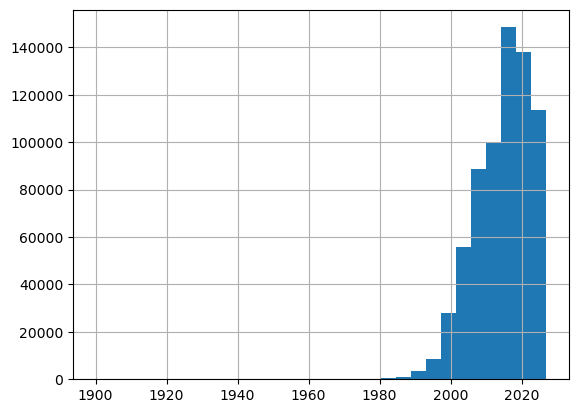

In [462]:
crash_parties_reduced_merge.Vehicle1Year.hist(bins=30)

Looking at a simple histogram to determine if there is any outliers it seems that by using 30 bins, there appears to be a large clump by the end of the 2010's model years

<Axes: >

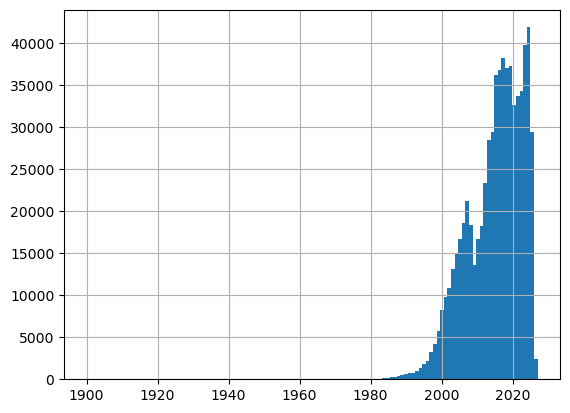

In [463]:
crash_parties_reduced_merge.Vehicle1Year.hist(bins=125)

<Axes: >

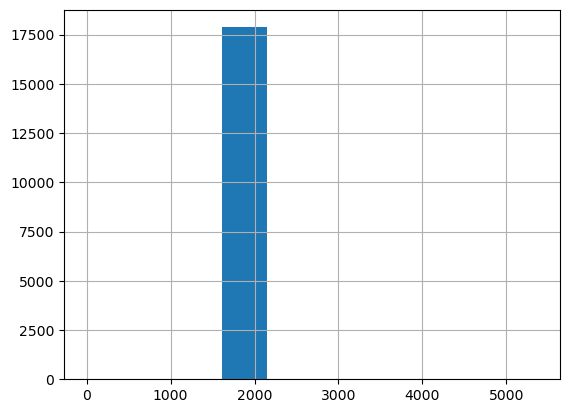

In [464]:
crash_parties_reduced_merge.Vehicle2Year.hist()

In [465]:
crash_parties_reduced_merge[crash_parties_reduced_merge['Vehicle2Year'] == 5372]['PartyId']

28840    13935066
Name: PartyId, dtype: int64

In [466]:
crash_parties_reduced_merge.Vehicle1Year.min()

1900.0

Double checking what the histogram plotted and having it include values as far back as the year 1900, I found that this records are incompletely plausabile since the model T by Ford was not created yet along with the chances that a car over a century old is unlikely to be usable in 2025 which this data set is based off of.

In [467]:
very_old_cars = crash_parties_reduced_merge[(crash_parties_reduced_merge['Vehicle1Year'] < 1980) | (crash_parties_reduced_merge['Vehicle2Year'] < 1980)]

In [468]:
very_old_cars

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithCode,MotorVehicleInvolvedWithDesc,...,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,Vehicle2TypeId,Vehicle2TypeDesc,Vehicle2Year,Vehicle2Make,Vehicle2Model,Vehicle2Color
19,4550250,2025-01-17,550,Unincorporated,BROADSIDE,Friday,False,True,C,OTHER MOTOR VEHICLE,...,WILLY,JEEP,RED,False,NaN,NaN,NaN,NaN,NaN,NaN
249,4550014,2025-01-24,1615,Unincorporated,SIDE SWIPE,Friday,True,False,C,OTHER MOTOR VEHICLE,...,FRHT,CASCADIA,WHI,False,31.0,SemiTrailer,1969.0,GIND,CHASSIS,BLK
949,4549408,2025-01-16,111,Santa Clara,REAR END,Thursday,False,True,E,PARKED MOTOR VEHICLE,...,CADILLAC,DEVILLE,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1418,4549010,2025-01-19,1709,Unincorporated,HIT OBJECT,Sunday,False,False,J,OTHER OBJECT,...,CHEV,PICKUP,BLK,False,NaN,NaN,NaN,NaN,NaN,NaN
2575,4547914,2025-01-20,609,Unincorporated,REAR END,Monday,True,True,C,OTHER MOTOR VEHICLE,...,FRHT,CASCADIA,WHI,False,31.0,SemiTrailer,1974.0,FONTAINE,FLATBED,BLK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761767,5116725,2025-10-05,1649,Fresno,HIT OBJECT,Sunday,True,True,I,FIXED OBJECT,...,CHEVROLET,CHEVELLE,GRAY,NaN,NaN,NaN,NaN,NaN,NaN,NaN
761883,5116650,2025-09-28,905,Fresno,BROADSIDE,Sunday,False,True,E,PARKED MOTOR VEHICLE,...,GMC,C-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
763765,5115595,2025-05-18,113,Fresno,SIDE SWIPE,Sunday,False,True,E,PARKED MOTOR VEHICLE,...,CHEVROLET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764277,5115288,2025-02-16,1800,Fresno,SIDE SWIPE,Sunday,False,False,C,OTHER MOTOR VEHICLE,...,CHEVROLET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It appears that there around 1554 rows who has recorded at least one model year that date back before the 1980s in the 2025 accident data 

<Axes: >

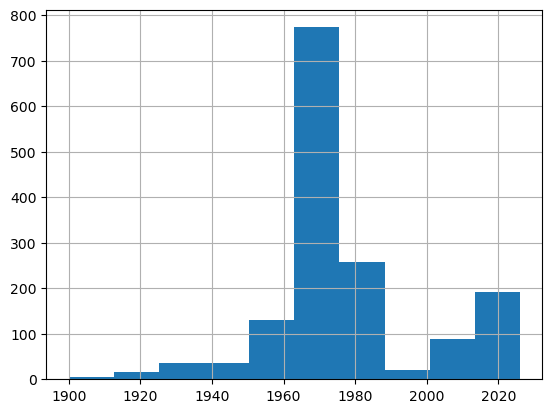

In [469]:
very_old_cars['Vehicle1Year'].hist()

Looking at just this subset of 1554 rows could be interesting since it could help show some more information regarding accidents involving cars pre 1980

In [470]:
very_old_cars.head()

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithCode,MotorVehicleInvolvedWithDesc,...,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,Vehicle2TypeId,Vehicle2TypeDesc,Vehicle2Year,Vehicle2Make,Vehicle2Model,Vehicle2Color
19,4550250,2025-01-17,550,Unincorporated,BROADSIDE,Friday,False,True,C,OTHER MOTOR VEHICLE,...,WILLY,JEEP,RED,False,NaN,NaN,NaN,NaN,NaN,NaN
249,4550014,2025-01-24,1615,Unincorporated,SIDE SWIPE,Friday,True,False,C,OTHER MOTOR VEHICLE,...,FRHT,CASCADIA,WHI,False,31.0,SemiTrailer,1969.0,GIND,CHASSIS,BLK
949,4549408,2025-01-16,111,Santa Clara,REAR END,Thursday,False,True,E,PARKED MOTOR VEHICLE,...,CADILLAC,DEVILLE,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1418,4549010,2025-01-19,1709,Unincorporated,HIT OBJECT,Sunday,False,False,J,OTHER OBJECT,...,CHEV,PICKUP,BLK,False,NaN,NaN,NaN,NaN,NaN,NaN
2575,4547914,2025-01-20,609,Unincorporated,REAR END,Monday,True,True,C,OTHER MOTOR VEHICLE,...,FRHT,CASCADIA,WHI,False,31.0,SemiTrailer,1974.0,FONTAINE,FLATBED,BLK


In [471]:
very_old_car_year_data = pd.DataFrame.from_dict(Counter(very_old_cars['Vehicle1Year']) + Counter(very_old_cars['Vehicle2Year']), orient = 'index').reset_index()

In [472]:
very_old_car_year_data.head()

,index,0
0,1958.0,11
1,2015.0,21
2,1978.0,109
3,1955.0,15
4,2011.0,13


In [473]:
Injuries_counter = pd.DataFrame.from_dict(Counter(crash_parties_reduced_merge['NumberInjured']) + Counter(crash_parties_reduced_merge['NumberKilled']), orient = 'index').reset_index()

In [474]:
Injuries_counter

,index,0
0,1.0,200347
1,0.0,1015027
2,3.0,20399
3,4.0,6872
4,2.0,65701
...,...,...
61429,NaN,1
61430,NaN,1
61431,NaN,1
61432,NaN,1


In [475]:
Injuries_counter.columns = ['Count', 'Frequency']  # Rename columns appropriately

In [476]:
crash_parties_reduced_merge['NumberInjured'].describe() 

count    656714.000000
mean          0.668938
std           0.953458
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          23.000000
Name: NumberInjured, dtype: float64

In [477]:
crash_parties_reduced_merge = crash_parties_reduced_merge.drop(crash_parties_reduced_merge[crash_parties_reduced_merge['NumberKilled'] == -1].index)

In [478]:
crash_parties_reduced_merge['NumberKilled'].describe()

count    655655.000000
mean          0.006447
std           0.090042
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
Name: NumberKilled, dtype: float64

<Axes: >

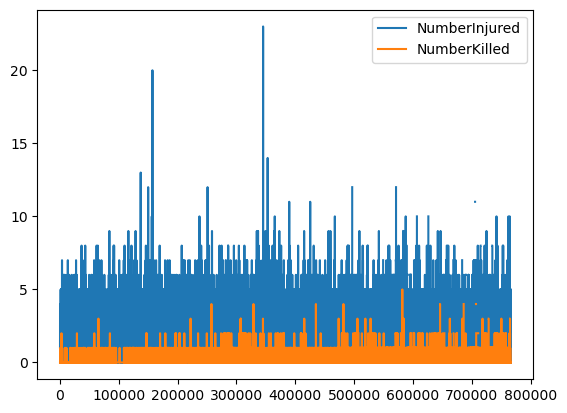

In [479]:
crash_parties_reduced_merge.plot(y =['NumberInjured','NumberKilled'])

<Axes: xlabel='NumberInjured'>

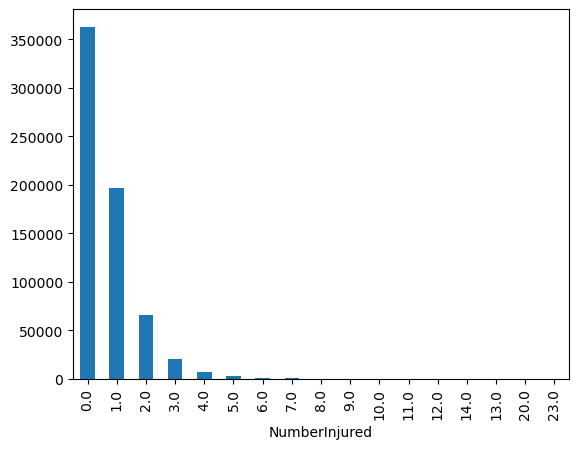

In [480]:
crash_parties_reduced_merge['NumberInjured'].value_counts().plot(kind='bar')

<Axes: xlabel='NumberKilled'>

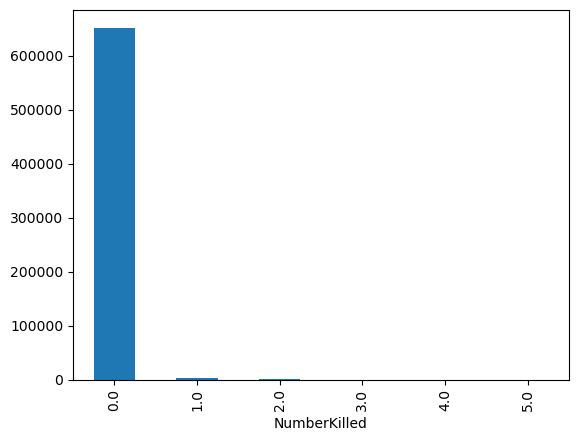

In [481]:
# Create a figure and axes
crash_parties_reduced_merge['NumberKilled'].value_counts().plot(kind='bar')


In [482]:
modern_vehicle_crashes = crash_parties_reduced_merge.drop(crash_parties_reduced_merge[crash_parties_reduced_merge['Vehicle2Year'] < 1980].index)

In [483]:
modern_vehicle_crashes = crash_parties_reduced_merge.drop(crash_parties_reduced_merge[crash_parties_reduced_merge['Vehicle1Year'] < 1980].index)

So based on above information, I removed all the Year Models under 1980 since it appears that they account for very little for recorded accidents in CA. However another problem that I am now encountering is that not all accidents involve a second vehicle

In [484]:
modern_vehicle_crashes[['Vehicle1Year','Vehicle2Year']].describe()

,Vehicle1Year,Vehicle2Year
count,685640.000000,17864.000000
mean,2014.685660,2013.899966
std,7.585935,47.239593
min,1980.000000,0.000000
25%,2010.000000,2008.000000
50%,2016.000000,2018.000000
75%,2021.000000,2022.000000
max,2027.000000,5372.000000


It seems that there are rows where the model year involved is 2027 which I am assuming is a data entry mistake since they would not exist in 2025. Along with since vehicle 2 is an inconsistent entry in the dataset so for further simplicity and its around 2-3% of the vehicle1 size it should not make an impact to drop this column as well.

In [485]:
modern_vehicle_crashes.loc[modern_vehicle_crashes['Vehicle1Year'] == 2027, 'Vehicle1Year'] = 2026 #Reassign the 2027 model years to 2026

In [486]:
modern_vehicle_crashes[['Vehicle1Year','Vehicle2Year']].describe()

,Vehicle1Year,Vehicle2Year
count,685640.000000,17864.000000
mean,2014.685651,2013.899966
std,7.585921,47.239593
min,1980.000000,0.000000
25%,2010.000000,2008.000000
50%,2016.000000,2018.000000
75%,2021.000000,2022.000000
max,2026.000000,5372.000000


In [487]:
modern_vehicle_crashes

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithCode,MotorVehicleInvolvedWithDesc,...,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,Vehicle2TypeId,Vehicle2TypeDesc,Vehicle2Year,Vehicle2Make,Vehicle2Model,Vehicle2Color
0,4550265,2025-01-18,1520,Unincorporated,OVERTURNED,Saturday,True,True,A,NON-COLLISION,...,KIA,SORENTO,BLU,False,NaN,NaN,NaN,NaN,NaN,NaN
1,4550265,2025-01-18,1520,Unincorporated,OVERTURNED,Saturday,True,True,A,NON-COLLISION,...,FORD,RANGER,WHI,True,NaN,NaN,NaN,NaN,NaN,NaN
2,4550264,2025-01-10,828,San Mateo,REAR END,Friday,False,False,C,OTHER MOTOR VEHICLE,...,HOND,ODY,WHI,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4550264,2025-01-10,828,San Mateo,REAR END,Friday,False,False,C,OTHER MOTOR VEHICLE,...,HYUN,ACC,SIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4550263,2025-01-23,845,Los Angeles,SIDE SWIPE,Thursday,True,False,C,OTHER MOTOR VEHICLE,...,NISS,ALTIMA,BLK,False,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766592,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,C,OTHER MOTOR VEHICLE,...,TOYOTA,PRIUS,GRAY,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766593,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,C,OTHER MOTOR VEHICLE,...,GMC,SIERRA,BLACK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766594,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,C,OTHER MOTOR VEHICLE,...,NISSAN,ALTIMA,GRAY,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766595,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,C,OTHER MOTOR VEHICLE,...,TOYOTA,COROLLA,WHITE,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [488]:
modern_vehicle_crashes[['Vehicle2Year','Vehicle2TypeId','Vehicle2TypeDesc','Vehicle2Make','Vehicle2Model','Vehicle2Color']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 685640 entries, 0 to 766596
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Vehicle2Year      17864 non-null  float64
 1   Vehicle2TypeId    18900 non-null  float64
 2   Vehicle2TypeDesc  18900 non-null  object 
 3   Vehicle2Make      18719 non-null  object 
 4   Vehicle2Model     17754 non-null  object 
 5   Vehicle2Color     18406 non-null  object 
dtypes: float64(2), object(4)
memory usage: 36.6+ MB


In [489]:
modern_vehicle_crashes =modern_vehicle_crashes.drop(['Vehicle2Year','Vehicle2TypeId','Vehicle2TypeDesc','Vehicle2Make','Vehicle2Model','Vehicle2Color','MotorVehicleInvolvedWithCode'],axis = 1)

In [490]:
Vehicle1Model =modern_vehicle_crashes['Vehicle1Model'].unique()

In [491]:
len(Vehicle1Model)

16794

In [492]:
Vehicle1TypeDesc = modern_vehicle_crashes['Vehicle1TypeDesc'].unique()

In [493]:
Vehicle1TypeDesc

array(['SportUtilityVehicle', 'PickupsAndPanels', 'MiniVan',
       'PassengerCarStationWagonJeep', 'TruckTractor', 'PoliceCar',
       'TwoAxleTruck', 'OtherUnknownHitAndRunDriver', 'Motorcycle',
       'MotorizedBicycle', 'TwoAxleTowTruck', 'AllTerrainVehicle',
       'MotorHomeGreaterThan40FeetInLength', 'HmThreeAxleTankTruck',
       'FireTruck', 'PublicTransitAuthority', 'ThreeOrMoreAxleTruck',
       'ThreeAxleTankTruck', 'TrailerCoach',
       'MiscMotorVehicleSnowmobileGolfCart', 'Bicycle', 'PullTrailer',
       'UtilityTrailer', 'EmergencyVehicleOnEmergencyRunOrPursuit',
       'HmPickupAndPanelTruck', 'TourBus', 'OtherCommercial',
       'ElectricBicycles', 'PickupWithCamper',
       'SchoolBusContractualTypeII', 'SchoolBusPublicTypeII',
       'ImplementOfHusbandry', nan, 'NonCommercialBus',
       'SchoolBusPublicTypeI', 'HmwThreeAxleTankTruck',
       'GeneralPublicParatransitVehicle', 'HmwPickupWithCamper',
       'HmPassengerCarStationWagonJeep', 'MotorHome40FeetOrLessIn

In [494]:
modern_vehicle_crashes['Vehicle1Make'].unique()

array(['KIA', 'FORD', 'HOND', ..., 'ZHEJIANG TAOTAO VEHICLES ',
       'ARIEL RIDER', 'STRIPER'], dtype=object)

In [495]:
modern_vehicle_crashes['Vehicle1Make'].unique()

array(['KIA', 'FORD', 'HOND', ..., 'ZHEJIANG TAOTAO VEHICLES ',
       'ARIEL RIDER', 'STRIPER'], dtype=object)

In [496]:
modern_vehicle_crashes.groupby('CollisionId')['Vehicle1Make'].unique()

CollisionId
4522711                  [DODGE]
4522894                   [CHEV]
4522959             [FORD, CHEV]
4523106                   [TOYT]
4523121             [JEEP, TOYT]
                   ...          
5122949         [CHEVROLET, GMC]
5122950    [TOYOTA, FORD, HONDA]
5122951                   [FORD]
5122952           [TOYOTA, FORD]
5122953                 [TOYOTA]
Name: Vehicle1Make, Length: 383004, dtype: object

In [497]:
modern_vehicle_crashes[modern_vehicle_crashes['Vehicle1Make'] == 'JEEP']

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,...,GenderCode,GenderDescription,StatedAge,DriverLicenseClass,Vehicle1TypeDesc,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
7,4550261,2025-01-20,1230,Unincorporated,BROADSIDE,Monday,False,True,OTHER MOTOR VEHICLE,3.0,...,M,MALE,65.0,C,SportUtilityVehicle,2012.0,JEEP,LIBERTY,BLK,True
31,4550242,2025-01-15,1625,Unincorporated,REAR END,Wednesday,True,True,OTHER MOTOR VEHICLE,3.0,...,F,FEMALE,66.0,C,SportUtilityVehicle,2023.0,JEEP,LAREDO,WHI,False
76,4550189,2025-01-18,22,Unincorporated,REAR END,Saturday,True,True,OTHER MOTOR VEHICLE,0.0,...,M,MALE,44.0,C,SportUtilityVehicle,2017.0,JEEP,CHEROKEE,BLK,False
77,4550189,2025-01-18,22,Unincorporated,REAR END,Saturday,True,True,OTHER MOTOR VEHICLE,0.0,...,M,MALE,31.0,C,SportUtilityVehicle,2017.0,JEEP,CHEROKEE,SIL,True
81,4550185,2025-01-24,1748,Los Angeles,SIDE SWIPE,Friday,True,False,OTHER MOTOR VEHICLE,0.0,...,M,MALE,41.0,C,SportUtilityVehicle,2020.0,JEEP,GRAND CHEROKEE,BLK,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766182,5105726,2025-07-13,1313,Orange,SIDE SWIPE,Sunday,False,False,PARKED MOTOR VEHICLE,2.0,...,NaN,NaN,NaN,NaN,SportUtilityVehicle,2015.0,JEEP,WRANGLER,GRAY,NaN
766340,5105630,2025-06-12,1658,Orange,SIDE SWIPE,Thursday,False,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,65.0,C,SportUtilityVehicle,2012.0,JEEP,CHEROKEE,WHITE,NaN
766367,5105618,2025-06-07,708,Orange,BROADSIDE,Saturday,False,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,61.0,C,PassengerCarStationWagonJeep,2025.0,JEEP,WRANGLER,WHITE,NaN
766381,5105610,2025-06-04,1923,Orange,BROADSIDE,Wednesday,False,True,OTHER MOTOR VEHICLE,0.0,...,F,FEMALE,17.0,C,PassengerCarStationWagonJeep,2023.0,JEEP,RENEGADE,BLACK,NaN


In [498]:
modern_vehicle_crashes[modern_vehicle_crashes['CollisionId'] == 5122949]

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,...,GenderCode,GenderDescription,StatedAge,DriverLicenseClass,Vehicle1TypeDesc,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
759237,5122949,2025-12-30,1650,Fresno,REAR END,Tuesday,False,False,OTHER MOTOR VEHICLE,0.0,...,F,FEMALE,44.0,C,PickupsAndPanels,2017.0,CHEVROLET,SILVERADO,BLACK,NaN
759238,5122949,2025-12-30,1650,Fresno,REAR END,Tuesday,False,False,OTHER MOTOR VEHICLE,0.0,...,NaN,NaN,NaN,NaN,PassengerCarStationWagonJeep,2010.0,GMC,ACADIA,WHITE,NaN


In [499]:
modern_vehicle_crashes[modern_vehicle_crashes['Vehicle1TypeDesc'].isna()]

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,...,GenderCode,GenderDescription,StatedAge,DriverLicenseClass,Vehicle1TypeDesc,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
1698,4548700,2025-01-03,1054,Truckee,BROADSIDE,Friday,False,True,OTHER MOTOR VEHICLE,0.0,...,F,FEMALE,NaN,C,NaN,2020.0,TOYOTA,NaN,NaN,NaN
1699,4548700,2025-01-03,1054,Truckee,BROADSIDE,Friday,False,True,OTHER MOTOR VEHICLE,0.0,...,F,FEMALE,NaN,C,NaN,2013.0,HONDA,NaN,NaN,NaN
5213,4545444,2025-01-01,700,San Jose,SIDE SWIPE,Wednesday,False,True,OTHER MOTOR VEHICLE,2.0,...,F,FEMALE,NaN,C,NaN,2012.0,TOYOTA,NaN,NaN,NaN
5214,4545444,2025-01-01,700,San Jose,SIDE SWIPE,Wednesday,False,True,OTHER MOTOR VEHICLE,2.0,...,M,MALE,NaN,U,NaN,2006.0,NISSAN,NaN,NaN,NaN
5254,4545394,2025-01-01,2328,San Jose,BROADSIDE,Wednesday,False,True,PARKED MOTOR VEHICLE,1.0,...,NaN,NaN,NaN,NaN,NaN,1990.0,HONDA,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764925,5110331,2025-12-07,2140,San Jose,REAR END,Sunday,False,False,OTHER MOTOR VEHICLE,1.0,...,F,FEMALE,NaN,C,NaN,2016.0,TOYOTA,NaN,NaN,NaN
764990,5110122,2025-12-04,1845,San Jose,REAR END,Thursday,False,True,OTHER MOTOR VEHICLE,1.0,...,F,FEMALE,NaN,C,NaN,2013.0,ACURA,NaN,NaN,NaN
764991,5110122,2025-12-04,1845,San Jose,REAR END,Thursday,False,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,NaN,C,NaN,2013.0,HYUNDAI,NaN,NaN,NaN
765037,5109692,2025-10-06,120,San Francisco,REAR END,Monday,False,False,OTHER MOTOR VEHICLE,1.0,...,M,MALE,NaN,C,NaN,2023.0,CHEVROLET,NaN,NaN,NaN


In [500]:
modern_vehicle_crashes.sort_values(by = ['Vehicle1TypeDesc'])

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,...,GenderCode,GenderDescription,StatedAge,DriverLicenseClass,Vehicle1TypeDesc,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
694220,4984327,2025-08-30,1400,Pismo Dunes Pk Dist,OVERTURNED,Saturday,False,False,NON-COLLISION,1.0,...,F,FEMALE,NaN,U,AllTerrainVehicle,2010.0,YAMAHA,NaN,NaN,NaN
625431,4955500,2025-10-24,1631,Modesto,HIT OBJECT,Friday,False,False,OTHER OBJECT,1.0,...,M,MALE,66.0,A,AllTerrainVehicle,1998.0,HONDA,CR,NaN,NaN
146847,4639593,2025-01-31,1749,Redlands,BROADSIDE,Friday,False,False,MOTOR VEHICLE ON OTHER ROADWAY,1.0,...,F,FEMALE,NaN,NaN,AllTerrainVehicle,2006.0,HONDA,NaN,NaN,NaN
458756,4835616,2025-06-07,2139,Riverside,REAR END,Saturday,False,False,PARKED MOTOR VEHICLE,0.0,...,M,MALE,15.0,U,AllTerrainVehicle,2003.0,POLARIS,PREDATOR,GRY,NaN
85920,4603313,2025-03-09,1926,Paradise,OVERTURNED,Sunday,False,False,NON-COLLISION,1.0,...,M,MALE,55.0,C,AllTerrainVehicle,2016.0,POLARIS,RANGER,BLK,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764925,5110331,2025-12-07,2140,San Jose,REAR END,Sunday,False,False,OTHER MOTOR VEHICLE,1.0,...,F,FEMALE,NaN,C,NaN,2016.0,TOYOTA,NaN,NaN,NaN
764990,5110122,2025-12-04,1845,San Jose,REAR END,Thursday,False,True,OTHER MOTOR VEHICLE,1.0,...,F,FEMALE,NaN,C,NaN,2013.0,ACURA,NaN,NaN,NaN
764991,5110122,2025-12-04,1845,San Jose,REAR END,Thursday,False,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,NaN,C,NaN,2013.0,HYUNDAI,NaN,NaN,NaN
765037,5109692,2025-10-06,120,San Francisco,REAR END,Monday,False,False,OTHER MOTOR VEHICLE,1.0,...,M,MALE,NaN,C,NaN,2023.0,CHEVROLET,NaN,NaN,NaN


It seems that Model is not safe from errors as well since some rows are missing values or spelled incorrectly and it seems in feasible to determine which one is wrong or not since theres nearly 17000 unique values for model name. However it seems more possible to accomplish with Vehicle make since its only around 4000. It also seems that collsionID has been duplicated for the same accident instead of listing them in one record.

In [501]:
test = modern_vehicle_crashes.drop_duplicates().CollisionId.value_counts().gt(1)

Filtering out rows that have reuse the same CollisionId

In [511]:
duplicated_unique_crashes = modern_vehicle_crashes.loc[modern_vehicle_crashes.CollisionId.isin(test[test].index)]

It appears that 554304 rows are filtered out with reusing Collision IDs

In [515]:
unique_crashes = modern_vehicle_crashes.drop(duplicated_unique_crashes.index) #Dropping the duplicated rows from the original dataset and creating a new dcataset from it

In [513]:
unique_crashes

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,...,GenderCode,GenderDescription,StatedAge,DriverLicenseClass,Vehicle1TypeDesc,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
4,4550263,2025-01-23,845,Los Angeles,SIDE SWIPE,Thursday,True,False,OTHER MOTOR VEHICLE,0.0,...,M,MALE,33.0,C,PassengerCarStationWagonJeep,2024.0,NISS,ALTIMA,BLK,False
6,4550262,2025-01-15,1230,Santa Paula,HIT OBJECT,Wednesday,True,False,OTHER OBJECT,0.0,...,M,MALE,57.0,C,PassengerCarStationWagonJeep,2010.0,TOYT,YARIS,SIL,False
11,4550259,2025-01-15,25,Unincorporated,HIT OBJECT,Wednesday,True,True,FIXED OBJECT,0.0,...,M,MALE,23.0,U,SportUtilityVehicle,2024.0,KIA,TELLURIDE,WHI,True
14,4550257,2025-01-17,2330,Oakland,HIT OBJECT,Friday,True,True,FIXED OBJECT,0.0,...,F,FEMALE,23.0,C,PassengerCarStationWagonJeep,2007.0,TOYT,CAMRY,WHI,True
20,4550250,2025-01-17,550,Unincorporated,BROADSIDE,Friday,False,True,OTHER MOTOR VEHICLE,0.0,...,M,MALE,21.0,C,PickupsAndPanels,2009.0,TOYT,TACOMA,WHI,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766551,5105506,2025-05-03,209,Orange,HIT OBJECT,Saturday,False,True,FIXED OBJECT,0.0,...,M,MALE,22.0,C,PassengerCarStationWagonJeep,2023.0,MAZDA,CX-5,GRAY,NaN
766575,5105497,2025-04-29,707,Orange,VEHICLE/PEDESTRAIN,Tuesday,False,False,PEDESTRIAN,1.0,...,F,FEMALE,44.0,C,PickupsAndPanels,2019.0,FORD,F-150,WHITE,NaN
766576,5105496,2025-04-29,537,Orange,HIT OBJECT,Tuesday,False,False,FIXED OBJECT,0.0,...,M,MALE,31.0,A,TruckTractor,2021.0,FRIEGHTLINER,CASCADIA,WHITE,NaN
766585,5105492,2025-04-27,1145,Orange,BROADSIDE,Sunday,False,False,BICYCLE,0.0,...,F,FEMALE,66.0,C,SportUtilityVehicle,2019.0,MERCEDES-BENZ,GLC300,WHITE,NaN


In [514]:
modern_vehicle_crashes

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,...,GenderCode,GenderDescription,StatedAge,DriverLicenseClass,Vehicle1TypeDesc,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
0,4550265,2025-01-18,1520,Unincorporated,OVERTURNED,Saturday,True,True,NON-COLLISION,1.0,...,F,FEMALE,22.0,C,SportUtilityVehicle,2011.0,KIA,SORENTO,BLU,False
1,4550265,2025-01-18,1520,Unincorporated,OVERTURNED,Saturday,True,True,NON-COLLISION,1.0,...,M,MALE,37.0,C,PickupsAndPanels,2003.0,FORD,RANGER,WHI,True
2,4550264,2025-01-10,828,San Mateo,REAR END,Friday,False,False,OTHER MOTOR VEHICLE,1.0,...,F,FEMALE,60.0,C,MiniVan,2019.0,HOND,ODY,WHI,NaN
3,4550264,2025-01-10,828,San Mateo,REAR END,Friday,False,False,OTHER MOTOR VEHICLE,1.0,...,M,MALE,34.0,C,PassengerCarStationWagonJeep,2016.0,HYUN,ACC,SIL,NaN
4,4550263,2025-01-23,845,Los Angeles,SIDE SWIPE,Thursday,True,False,OTHER MOTOR VEHICLE,0.0,...,M,MALE,33.0,C,PassengerCarStationWagonJeep,2024.0,NISS,ALTIMA,BLK,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766592,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,34.0,C,PassengerCarStationWagonJeep,2007.0,TOYOTA,PRIUS,GRAY,NaN
766593,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,18.0,C,PickupsAndPanels,2004.0,GMC,SIERRA,BLACK,NaN
766594,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,42.0,C,PassengerCarStationWagonJeep,2017.0,NISSAN,ALTIMA,GRAY,NaN
766595,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,55.0,C,PassengerCarStationWagonJeep,2014.0,TOYOTA,COROLLA,WHITE,NaN


In [516]:
duplicated_unique_crashes

,CollisionId,Crash Date Time,Crash Time Description,City Name,Collision Type Description,Day Of Week,IsHighwayRelated,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,...,GenderCode,GenderDescription,StatedAge,DriverLicenseClass,Vehicle1TypeDesc,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
0,4550265,2025-01-18,1520,Unincorporated,OVERTURNED,Saturday,True,True,NON-COLLISION,1.0,...,F,FEMALE,22.0,C,SportUtilityVehicle,2011.0,KIA,SORENTO,BLU,False
1,4550265,2025-01-18,1520,Unincorporated,OVERTURNED,Saturday,True,True,NON-COLLISION,1.0,...,M,MALE,37.0,C,PickupsAndPanels,2003.0,FORD,RANGER,WHI,True
2,4550264,2025-01-10,828,San Mateo,REAR END,Friday,False,False,OTHER MOTOR VEHICLE,1.0,...,F,FEMALE,60.0,C,MiniVan,2019.0,HOND,ODY,WHI,NaN
3,4550264,2025-01-10,828,San Mateo,REAR END,Friday,False,False,OTHER MOTOR VEHICLE,1.0,...,M,MALE,34.0,C,PassengerCarStationWagonJeep,2016.0,HYUN,ACC,SIL,NaN
7,4550261,2025-01-20,1230,Unincorporated,BROADSIDE,Monday,False,True,OTHER MOTOR VEHICLE,3.0,...,M,MALE,65.0,C,SportUtilityVehicle,2012.0,JEEP,LIBERTY,BLK,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766591,5105488,2025-04-26,1522,Orange,BROADSIDE,Saturday,False,False,OTHER MOTOR VEHICLE,1.0,...,M,MALE,21.0,C,PassengerCarStationWagonJeep,2015.0,KIA,OPTIMA,GRAY,NaN
766592,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,34.0,C,PassengerCarStationWagonJeep,2007.0,TOYOTA,PRIUS,GRAY,NaN
766593,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,18.0,C,PickupsAndPanels,2004.0,GMC,SIERRA,BLACK,NaN
766594,5105487,2025-04-26,1001,Orange,SIDE SWIPE,Saturday,True,True,OTHER MOTOR VEHICLE,1.0,...,M,MALE,42.0,C,PassengerCarStationWagonJeep,2017.0,NISSAN,ALTIMA,GRAY,NaN


Going forward I have split the main dataset into two different datasets one that is fully unique and the other that contains the overlapping collisionIDs. The overlap appears to consist of almost half the records in that dataset

In [523]:
len(duplicated_unique_crashes['CollisionId'].unique())

251668

In [526]:
unique_crashes.to_csv("unique_crashes.csv")

In [527]:
duplicated_unique_crashes.to_csv("overlapping_unique_crashes.csv")